# Support Ticket Clustering

In this notebook, we analyze a dataset of support tickets in order to create clusters, which will be assigned to the proper support team.

## Plan

Convert the tickets subject + body into embeddings to train a unsupervised clustering model. Thus, use a local use a local LLM to obtain a description per cluster as well as a TF-IDF analysis to extract representative keywords.

1. TF-IDF analysis for cleaning boilerplate and noise.

## Packages

In [35]:
# Data handling
import hashlib
import json
import re
import time
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd

# Text vectorization
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords

# Embeddings
import torch
from sentence_transformers import SentenceTransformer

# Plotting
import matplotlib.pyplot as plt

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\bruno.santos\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
g:\Projects\Voll Technical Challenge\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Settings

In [2]:
# Matplotlib settings
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 90)

# Shared tokenizer pattern: accent-aware words of 2+ characters.
TOKEN_PATTERN = r"(?u)\b\w\w+\b"
TOKEN_STOPWORDS = stopwords.words("portuguese")

## Dataset basic exploration

In [3]:
DATASET_PATH = 'dataset/classificacao_atendimento.csv'

tickets_df = pd.read_csv(DATASET_PATH, sep=',', encoding='utf-8')
NUMBER_DOCS = len(tickets_df)
tickets_df

,ticket_id,subject,body
0,2,Erro na Autocompletação de Código do IntelliJ IDEA,"Prezado Suporte ao Cliente <name>,\n\nEstou escrevendo para trazer à sua atenção um pr..."
1,28,Problemas intermitentes de exibição após atualização de firmware,"Caro Suporte ao Cliente,\n\n Estou entrando em contato para relatar um problema com me..."
2,45,Pedido de Assistência para Administração de Servidores,"Prezado Suporte ao Cliente de Serviços de TI,\n\nEspero que esta mensagem o encontre b..."
3,46,NaN,"Prezado <name>,\n\nSentimos muito ao saber sobre o atraso na entrega do seu Apple Watc..."
4,63,Urgente: Relato de Falha na Bateria do MacBook Air M1 Adquirido na Loja Virtual,"Prezado Atendimento ao Cliente,<br><br>Recentemente adquiri um MacBook Air M1 em sua l..."
...,...,...,...
468,3980,Incidente de alta prioridade,"Caro Time de Suporte ao Cliente,\n\nEspero que esta mensagem o encontre bem. Estou esc..."
469,3983,Urgente: Interrupção de Serviço da AWS,"Caro time de Suporte de Serviços de TI,\n\nEstou entrando em contato para relatar uma ..."
470,3988,Problema de Cobrança: Cobranças Incorretas na Assinatura,"Caro Equipe de Suporte ao Cliente,\n\nEstou escrevendo para trazer à sua atenção uma d..."
471,3994,Assistência Necessária para Problema de Tela do Dell XPS 13,"Caro Time de Suporte ao Cliente, estou enfrentando um problema de cintilação na tela d..."


Check whether the ticket ID column is unique. If yes, convert it to the Dataframe index.

In [4]:
tickets_df["ticket_id"].is_unique

True

The checking above confirms that the ticket_id is unique. Thus, let us convert this column to index.

In [5]:
tickets_df.set_index("ticket_id", inplace=True)
tickets_df

,subject,body
ticket_id,,
2,Erro na Autocompletação de Código do IntelliJ IDEA,"Prezado Suporte ao Cliente <name>,\n\nEstou escrevendo para trazer à sua atenção um pr..."
28,Problemas intermitentes de exibição após atualização de firmware,"Caro Suporte ao Cliente,\n\n Estou entrando em contato para relatar um problema com me..."
45,Pedido de Assistência para Administração de Servidores,"Prezado Suporte ao Cliente de Serviços de TI,\n\nEspero que esta mensagem o encontre b..."
46,NaN,"Prezado <name>,\n\nSentimos muito ao saber sobre o atraso na entrega do seu Apple Watc..."
63,Urgente: Relato de Falha na Bateria do MacBook Air M1 Adquirido na Loja Virtual,"Prezado Atendimento ao Cliente,<br><br>Recentemente adquiri um MacBook Air M1 em sua l..."
...,...,...
3980,Incidente de alta prioridade,"Caro Time de Suporte ao Cliente,\n\nEspero que esta mensagem o encontre bem. Estou esc..."
3983,Urgente: Interrupção de Serviço da AWS,"Caro time de Suporte de Serviços de TI,\n\nEstou entrando em contato para relatar uma ..."
3988,Problema de Cobrança: Cobranças Incorretas na Assinatura,"Caro Equipe de Suporte ao Cliente,\n\nEstou escrevendo para trazer à sua atenção uma d..."


Basic information

In [6]:
tickets_df.info()

<class 'pandas.DataFrame'>
Index: 473 entries, 2 to 3996
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   subject  419 non-null    str  
 1   body     473 non-null    str  
dtypes: str(2)
memory usage: 11.1 KB


In [7]:
tickets_df.describe()

,subject,body
count,419,473
unique,419,473
top,Erro na Autocompletação de Código do IntelliJ IDEA,"Prezado Suporte ao Cliente <name>,\n\nEstou escrevendo para trazer à sua atenção um pr..."
freq,1,1


## TF-IDF analysis for cleaning

Before embedding or clustering anything, we need to know — with evidence —
which parts of these tickets carry information about *what the customer needs*, and which parts are
noise repeated across multiple messages.

Any similarity measure treats shared text as evidence of similarity. Therefore, very frequent words such as `obrigado` and `atenciosamente` across the tickets buried the structure we are actually seeking.

The analysis proceeds in eight steps:

1. **Document preparation and chars/tokens length analysis**
2. **Structural noise analysis**
3. **Terms frequency analysis**
4. **Phrasal frequency analysis**
5. **Text cleaning**
6. **Qualitative validation**

### Document preparation and chars/tokens length analysis

Merge `subject` and `body` into the `full_text` column A.K.A. **documents** (TF-IDF term).

In [8]:
# Keep the originals intact - the whole exercise is a before/after comparison.
cleaned_tickets_df = tickets_df.copy()

cleaned_tickets_df["subject"] = cleaned_tickets_df["subject"].fillna("").str.strip()
cleaned_tickets_df["body"] = cleaned_tickets_df["body"].fillna("").str.strip()

cleaned_tickets_df["full_text"] = (
    cleaned_tickets_df.apply(
        lambda row: row["body"] if row["subject"] == "" else row["subject"] + ". " + row["body"], axis=1)
)

cleaned_tickets_df

,subject,body,full_text
ticket_id,,,
2,Erro na Autocompletação de Código do IntelliJ IDEA,"Prezado Suporte ao Cliente <name>,\n\nEstou escrevendo para trazer à sua atenção um pr...","Erro na Autocompletação de Código do IntelliJ IDEA. Prezado Suporte ao Cliente <name>,..."
28,Problemas intermitentes de exibição após atualização de firmware,"Caro Suporte ao Cliente,\n\n Estou entrando em contato para relatar um problema com me...",Problemas intermitentes de exibição após atualização de firmware. Caro Suporte ao Clie...
45,Pedido de Assistência para Administração de Servidores,"Prezado Suporte ao Cliente de Serviços de TI,\n\nEspero que esta mensagem o encontre b...",Pedido de Assistência para Administração de Servidores. Prezado Suporte ao Cliente de ...
46,,"Prezado <name>,\n\nSentimos muito ao saber sobre o atraso na entrega do seu Apple Watc...","Prezado <name>,\n\nSentimos muito ao saber sobre o atraso na entrega do seu Apple Watc..."
63,Urgente: Relato de Falha na Bateria do MacBook Air M1 Adquirido na Loja Virtual,"Prezado Atendimento ao Cliente,<br><br>Recentemente adquiri um MacBook Air M1 em sua l...",Urgente: Relato de Falha na Bateria do MacBook Air M1 Adquirido na Loja Virtual. Preza...
...,...,...,...
3980,Incidente de alta prioridade,"Caro Time de Suporte ao Cliente,\n\nEspero que esta mensagem o encontre bem. Estou esc...","Incidente de alta prioridade. Caro Time de Suporte ao Cliente,\n\nEspero que esta mens..."
3983,Urgente: Interrupção de Serviço da AWS,"Caro time de Suporte de Serviços de TI,\n\nEstou entrando em contato para relatar uma ...","Urgente: Interrupção de Serviço da AWS. Caro time de Suporte de Serviços de TI,\n\nEst..."
3988,Problema de Cobrança: Cobranças Incorretas na Assinatura,"Caro Equipe de Suporte ao Cliente,\n\nEstou escrevendo para trazer à sua atenção uma d...",Problema de Cobrança: Cobranças Incorretas na Assinatura. Caro Equipe de Suporte ao Cl...


Characters and tokens stats

<Figure size 640x480 with 0 Axes>

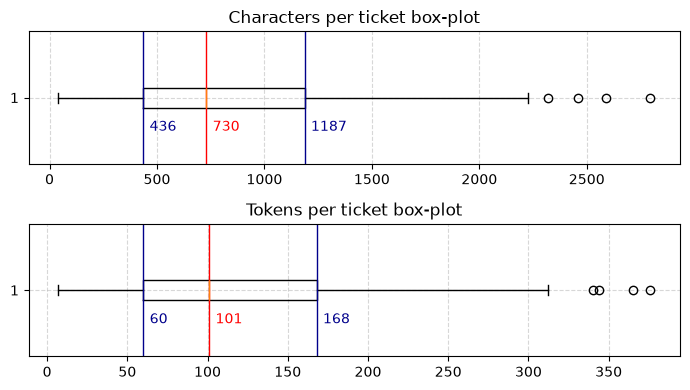

In [9]:
chars = cleaned_tickets_df["full_text"].str.len()
tokens = cleaned_tickets_df["full_text"].str.split(" ").str.len()

plt.clf()
fig, axs = plt.subplots(2, 1, figsize=(7, 4))

# Characters per ticket box-plot
axs[0].set_title("Characters per ticket box-plot")
axs[0].boxplot(chars, orientation="horizontal")
axs[0].grid(linestyle="--", alpha=0.5)

median_chars = chars.median()
axs[0].axvline(median_chars, color="red", linestyle="-", linewidth=1)
axs[0].text(median_chars + axs[0].get_xlim()[1] * 0.01, axs[0].get_ylim()[1] / 2, f"{median_chars:.0f}", color="red")

percentile_25_chars = chars.quantile(0.25)
axs[0].axvline(percentile_25_chars, color="darkblue", linestyle="-", linewidth=1)
axs[0].text(percentile_25_chars + axs[0].get_xlim()[1] * 0.01, axs[0].get_ylim()[1] / 2, f"{percentile_25_chars:.0f}", color="darkblue")

percentile_75_chars = chars.quantile(0.75)
axs[0].axvline(percentile_75_chars, color="darkblue", linestyle="-", linewidth=1)
axs[0].text(percentile_75_chars + axs[0].get_xlim()[1] * 0.01, axs[0].get_ylim()[1] / 2, f"{percentile_75_chars:.0f}", color="darkblue")

# Tokens per ticket box-plot
axs[1].set_title("Tokens per ticket box-plot")
axs[1].boxplot(tokens, orientation="horizontal")
axs[1].grid(linestyle="--", alpha=0.5)

median_tokens = tokens.median()
axs[1].axvline(median_tokens, color="red", linestyle="-", linewidth=1)
axs[1].text(median_tokens + axs[1].get_xlim()[1] * 0.01, axs[1].get_ylim()[1] / 2, f"{median_tokens:.0f}", color="red")

percentile_25_tokens = tokens.quantile(0.25)
axs[1].axvline(percentile_25_tokens, color="darkblue", linestyle="-", linewidth=1)
axs[1].text(percentile_25_tokens + axs[1].get_xlim()[1] * 0.01, axs[1].get_ylim()[1] / 2, f"{percentile_25_tokens:.0f}", color="darkblue")

percentile_75_tokens = tokens.quantile(0.75)
axs[1].axvline(percentile_75_tokens, color="darkblue", linestyle="-", linewidth=1)
axs[1].text(percentile_75_tokens + axs[1].get_xlim()[1] * 0.01, axs[1].get_ylim()[1] / 2, f"{percentile_75_tokens:.0f}", color="darkblue")

plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

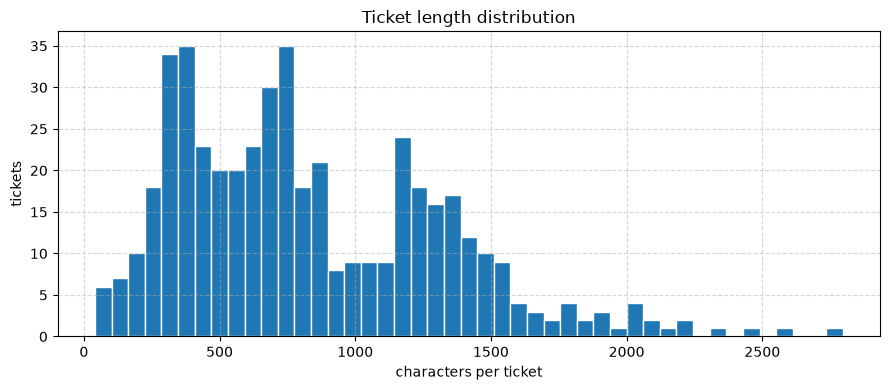

In [10]:
plt.clf()
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(cleaned_tickets_df["full_text"].str.len(), bins=45, color="tab:blue", edgecolor="white")
ax.set_xlabel("characters per ticket")
ax.set_ylabel("tickets")
ax.set_title("Ticket length distribution")
ax.grid(linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

### Structural noise analysis

Some noise is not a vocabulary problem: anonymisation, placeholders, HTML markup, and malformed rows.

In [11]:
ANGLE_SPAN_RE = re.compile(r"<[^<>\n]{1,60}>")

angle_spans = cleaned_tickets_df["full_text"].map(ANGLE_SPAN_RE.findall)
span_counts = Counter(s.lower() for spans in angle_spans for s in spans)
placeholders = Counter({k: v for k, v in span_counts.items() if not k.startswith("<br")})
n_br = int(cleaned_tickets_df["full_text"].str.count(r"(?i)<br\s*/?>").sum())

print("Structural noise")
print(f"  angle-bracket spans, total   : {sum(span_counts.values())}")
print(f"    HTML <br> variants         : {n_br}  (in {cleaned_tickets_df['full_text'].str.contains(r'(?i)<br').sum()} tickets)")
print(f"    anonymisation placeholders : {sum(placeholders.values())}  "
      f"({len(placeholders)} distinct kinds)")
print(f"  tickets containing >=1 placeholder: "
      f"{angle_spans.map(lambda s: any(not x.lower().startswith('<br') for x in s)).sum()} / {NUMBER_DOCS}")

Structural noise
  angle-bracket spans, total   : 1227
    HTML <br> variants         : 72  (in 7 tickets)
    anonymisation placeholders : 1155  (41 distinct kinds)
  tickets containing >=1 placeholder: 447 / 473


In [12]:
print("\n  Most common placeholders:")
for kind, count in placeholders.most_common(12):
    print(f"    {kind:<24}{count:>5}")
print("\n  The tokenizer discards < and >, but the words inside (name, tel_num, acc_num)")
print("  survive into the vocabulary.")


  Most common placeholders:
    <name>                    530
    <tel_num>                 263
    <acc_num>                 197
    <email>                    43
    <company_name>             20
    <email_address>            18
    <company>                  12
    <position>                 10
    <order_num>                10
    <date>                      7
    <purchase_date>             4
    <company name>              4

  The tokenizer discards < and >, but the words inside (name, tel_num, acc_num)
  survive into the vocabulary.


In [13]:
# Malformed bodies: one ticket stores its content as a JSON string.
json_bodies = cleaned_tickets_df["body"][cleaned_tickets_df["body"].str.startswith(("{", "["))]
print(f"Bodies that are JSON rather than prose: {len(json_bodies)}")
for tid, text in json_bodies.items():
    print(f"  ticket {tid}: {text[:110]}...")

Bodies that are JSON rather than prose: 1
  ticket 3299: {"greeting": "Caro Suporte ao Cliente,", "body": "Preciso de detalhes sobre o recurso de teclado destacável e ...


In [14]:
# Very short tickets: little signal, worth tracking downstream.
short = cleaned_tickets_df["full_text"][cleaned_tickets_df["full_text"].str.len() < 80].sort_values(key=lambda s: s.str.len())
print(f"\nTickets under 80 characters: {len(short)}")
for tid, text in short.items():
    print(f"  {tid} ({len(text):>3} chars): {text}")


Tickets under 80 characters: 4
  2416 ( 41 chars): O software fica sem resposta ao exportar.
  3902 ( 43 chars): Por favor, reduza a interrupção do serviço.
  2908 ( 45 chars): Melhorar a eficiência do sistema de tíquetes.
  3849 ( 59 chars): Problema com Anexo do Ticket. Precisa de resolução no Jira.


### Terms frequency analysis

In [15]:
document_tokens_counter = CountVectorizer(
    binary=True,
    token_pattern=TOKEN_PATTERN
)

document_tokens_matrix = document_tokens_counter.fit_transform(cleaned_tickets_df["full_text"])
vocabulary = document_tokens_counter.get_feature_names_out()
tokens_frequency = np.asarray(document_tokens_matrix.sum(axis=0)).ravel() / NUMBER_DOCS
tokens_frequency_order = np.argsort(-tokens_frequency)

In [16]:
terms_frequency = pd.DataFrame({
    "term": vocabulary[tokens_frequency_order], 
    "df_frac": tokens_frequency[tokens_frequency_order]
})
terms_frequency.index = np.arange(1, len(terms_frequency) + 1)

terms_frequency

,term,df_frac
1,de,0.970402
2,name,0.934461
3,suporte,0.892178
4,para,0.871036
5,estou,0.797040
...,...,...
3381,dê,0.002114
3382,895,0.002114
3383,18,0.002114
3384,ões,0.002114


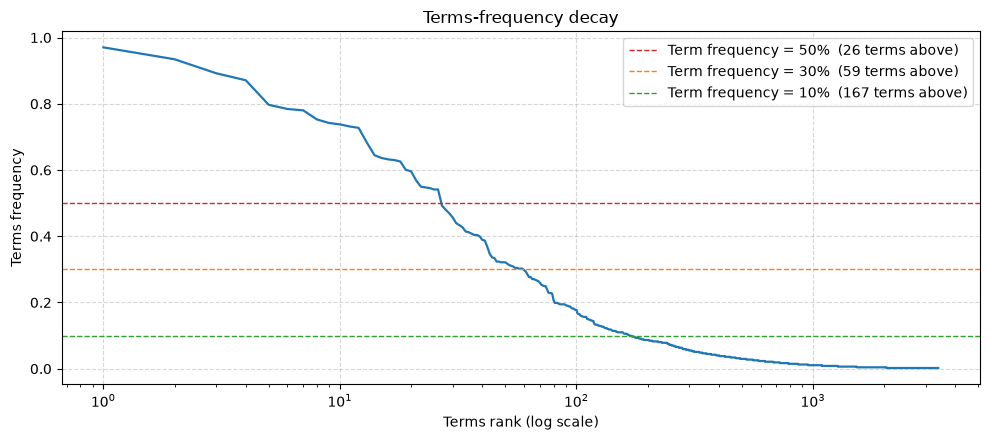

In [17]:
fig, ax = plt.subplots(figsize=(10, 4.5))

ax.plot(np.arange(1, len(terms_frequency) + 1), np.sort(terms_frequency["df_frac"])[::-1], lw=1.6)
ax.set_xscale("log")
for threshold, colour in [(0.5, "tab:red"), (0.3, "tab:orange"), (0.1, "tab:green")]:
    ax.axhline(threshold, ls="--", lw=1, color=colour,
               label=f"Term frequency = {threshold:.0%}  ({(terms_frequency['df_frac'] > threshold).sum()} terms above)")
ax.set_xlabel("Terms rank (log scale)")
ax.set_ylabel("Terms frequency")
ax.set_title("Terms-frequency decay")
ax.grid(linestyle="--", alpha=0.5)
ax.legend()

plt.tight_layout()
plt.show()

### Phrasal frequency analysis

Unigram frequency understates the problem. The real ceremony in these tickets is multi-word —
*"espero que esta mensagem o encontre bem"*, *"aguardo sua resposta rápida"* — and no unigram filter can
remove a phrase while keeping its component words available elsewhere.

In [ ]:
document_phrase_counter = CountVectorizer(
    binary=True,
    ngram_range=(3,15), # Phrases of 3 to 15 words
    token_pattern=TOKEN_PATTERN
)

document_phrases_matrix = document_phrase_counter.fit_transform(cleaned_tickets_df["full_text"])
phrases = document_phrase_counter.get_feature_names_out()
document_phrases_frequency = np.asarray(document_phrases_matrix.sum(axis=0)).ravel() / NUMBER_DOCS
document_phrases_frequency_order = np.argsort(-document_phrases_frequency)

In [23]:
phrases_frequency = pd.DataFrame({
    "term": phrases[document_phrases_frequency_order], 
    "df_frac": document_phrases_frequency[document_phrases_frequency_order]
})
phrases_frequency.index = np.arange(1, len(phrases_frequency) + 1)

phrases_frequency

,term,df_frac
1,suporte ao cliente,0.668076
2,estou escrevendo para,0.467230
3,obrigado pela sua,0.454545
4,espero que esta,0.295983
5,que esta mensagem,0.295983
...,...,...
573333,útil ter uma visão geral de quaisquer problemas conhecidos relacionados este modelo,0.002114
573334,útil ter uma visão geral de quaisquer problemas conhecidos relacionados este modelo ou,0.002114
573335,útil ter uma visão geral de quaisquer problemas conhecidos relacionados este modelo ou...,0.002114
573336,útil ter uma visão geral de quaisquer problemas conhecidos relacionados este modelo ou...,0.002114


Knowing *what* the boilerplate is does not yet tell us how to remove it safely. A global find-and-replace
for `"obrigado"` would also delete it from a sentence like *"Obrigado pela ajuda até agora, mas o problema
continua"* — destroying real content.

So measure **where** each boilerplate family occurs, as a fraction of document length. If greetings
cluster near 0.0 and signoffs near 1.0 while genuine signal spreads through the middle, then positional
rules (cut the first line, cut from the signoff to the end) are both safer and simpler than global
substitution. A signal control (`problema|erro|falha`) is included for contrast.

                             probe  tickets    df  median_pos  first_15%  last_25%
  greeting: caro/prezado + suporte      391 0.827       0.061      0.936     0.000
           greeting: olá/saudações        3 0.006       0.000      1.000     0.000
 pleasantry: espero...encontre bem      148 0.313       0.078      0.946     0.000
  pleasantry: aguardo sua resposta       89 0.188       0.916      0.000     1.000
 pleasantry: obrigado pela atenção      150 0.317       0.903      0.000     1.000
           signoff: atenciosamente      344 0.727       0.966      0.000     1.000
signoff: cordialmente/cumprimentos       12 0.025       0.941      0.000     1.000
    closing: obrigado (standalone)      369 0.780       0.912      0.000     1.000
           placeholder: <name> etc      447 0.945       0.970      0.034     0.834
   CONTROL - signal: problema/erro      294 0.622       0.372      0.278     0.141


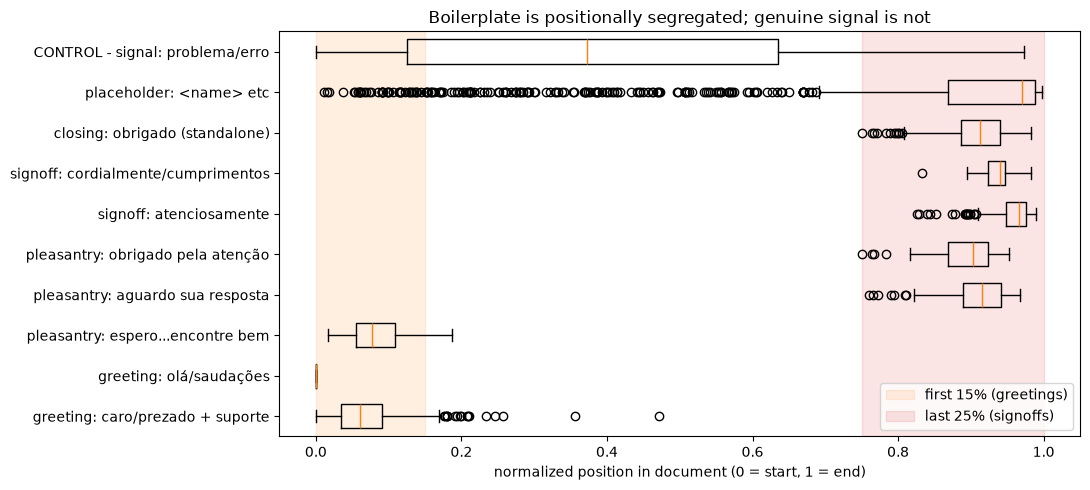

In [24]:
# Probe families of boilerplate, plus one genuine-signal control for contrast.
PROBES = {
    "greeting: caro/prezado + suporte":   r"(?i)\b(caro|cara|prezad[oa]s?)\b[^.\n]{0,60}\b(suporte|atendimento|equipe|time|cliente)\b",
    "greeting: olá/saudações":            r"(?i)^\s*(ol[áa]|sauda[çc][õo]es)\b",
    "pleasantry: espero...encontre bem":  r"(?i)espero que (esta|este)[^.]{0,40}encontre[^.]{0,20}bem",
    "pleasantry: aguardo sua resposta":   r"(?i)aguard(o|ando|amos)[^.]{0,30}resposta",
    "pleasantry: obrigado pela atenção":  r"(?i)obrigad[oa][^.]{0,40}aten[çc][ãa]o",
    "signoff: atenciosamente":            r"(?i)\batenciosamente\b",
    "signoff: cordialmente/cumprimentos": r"(?i)\b(cordialmente|melhores cumprimentos|atentamente)\b",
    "closing: obrigado (standalone)":     r"(?i)\bobrigad[oa]\b",
    "placeholder: <name> etc":            r"<[^<>\n]{1,60}>",
    "CONTROL - signal: problema/erro":    r"(?i)\b(problema|erro|falha|defeito)\b",
}

positions, rows = {}, []
for label, pattern in PROBES.items():
    rx = re.compile(pattern, re.M)
    found, n_tickets = [], 0
    for text in cleaned_tickets_df["full_text"]:
        matches = list(rx.finditer(text))
        if matches:
            n_tickets += 1
            found.extend(m.start() / len(text) for m in matches)
    if not found:
        continue
    found = np.array(found)
    positions[label] = found
    rows.append({"probe": label, "tickets": n_tickets, "df": n_tickets / NUMBER_DOCS,
                 "median_pos": np.median(found),
                 "first_15%": (found < 0.15).mean(), "last_25%": (found > 0.75).mean()})

print(pd.DataFrame(rows).to_string(index=False, float_format=lambda v: f"{v:.3f}"))

fig, ax = plt.subplots(figsize=(11, 5))
labels = list(positions)
ax.boxplot([positions[l] for l in labels], orientation="horizontal",
           tick_labels=labels, widths=.6)
ax.axvspan(0, 0.15, color="tab:orange", alpha=.12, label="first 15% (greetings)")
ax.axvspan(0.75, 1.0, color="tab:red", alpha=.12, label="last 25% (signoffs)")
ax.set_xlabel("normalized position in document (0 = start, 1 = end)")
ax.set_title("Boilerplate is positionally segregated; genuine signal is not")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Text cleaning

Every rule below traces to a measurement made above — nothing is included on intuition alone.

| # | Rule | Type | Evidence |
|---|---|---|---|
| 1 | Unwrap JSON-encoded bodies | structural | 1 ticket (3299) stores prose inside a JSON string |
| 2 | Replace `<br>` with newline | structural | 72 tags across 7 tickets |
| 3 | Remove `<placeholder>` spans | structural | 1,155 spans; `name` has frequency of 93.4%, `tel_num` 54.5%, `acc_num` 41.4% |
| 4 | Cut from the signoff marker to end | positional | signoff median position 0.966, p10 = 0.927 |
| 5 | Drop the leading salutation line | positional | greeting median position 0.061, 93.6% in first 15% |
| 6 | Remove pleasantry formulas | phrasal | `espero...encontre bem` DF 31.3%, `obrigado pela atenção` DF 31.7% |
| 7 | Stopword list at vectorizer level | lexical | 26 terms with frequency > 0.5 |

Two design decisions worth stating explicitly:

**Rules 4 and 5 are positional, not global.** The signoff cut only fires when the marker appears past 60%
of the document. Without that guard, a mid-body `"Obrigado pela ajuda até agora, mas o problema
continua..."` would silently truncate the actual complaint. The positional analysis is what makes the
0.60 threshold defensible rather than arbitrary.

**Stopwords are kept separate from text cleaning.** Text cleaning is destructive and belongs to the data
layer; stopword removal is a vectorizer parameter and stays reversible. Collapsing the two would make it
impossible to re-tokenise later with a different list.

Auxiliary methods

In [25]:
# --- Patterns, each traceable to a measurement above -------------------------
PLACEHOLDER_RE = re.compile(r"<[^<>\n]{1,60}>")
HTML_BR_RE = re.compile(r"(?i)<br\s*/?>")
HTML_TAG_RE = re.compile(r"<[^<>\n]{1,40}>")

GREETING_RE = re.compile(
    r"(?i)^\W*(car[oa]s?|prezad[oa]s?|ol[áa]|oi|sauda[çc][õo]es|bom dia|boa tarde|boa noite)"
    r"\b[^,\n]{0,90}[,:\n]")

SIGNOFF_RE = re.compile(
    r"(?i)\n?\s*\b(atenciosamente|cordialmente|atentamente|respeitosamente|"
    r"melhores cumprimentos|abra[çc]os|agradecemos por escolher|obrigad[oa])\b[\s\S]*$")

PLEASANTRY_RES = [
    re.compile(r"(?i)espero que (esta|este|o|a)\b[^.!?]{0,60}(encontre|encontrem)[^.!?]{0,25}bem[.!?]?"),
    re.compile(r"(?i)espero que (voc[êe]s?|o senhor|a senhora)\b[^.!?]{0,40}(esteja|estejam)[^.!?]{0,15}bem[.!?]?"),
    re.compile(r"(?i)aguard(o|ando|amos)[^.!?]{0,45}(resposta|retorno|assist[êe]ncia)[^.!?]{0,25}[.!?]?"),
    re.compile(r"(?i)agrade[çc](o|emos)[^.!?]{0,45}(antecipadamente|aten[çc][ãa]o|assist[êe]ncia)[^.!?]{0,25}[.!?]?"),
    re.compile(r"(?i)obrigad[oa][^.!?]{0,45}(aten[çc][ãa]o|assist[êe]ncia|apoio|suporte|compreens[ãa]o)[^.!?]{0,25}[.!?]?"),
    re.compile(r"(?i)\b(sinta-se [àa] vontade|fique [àa] vontade)\b[^.!?]{0,70}[.!?]?"),
    re.compile(r"(?i)\bpor favor,?\s*(me )?(avise|informe|deixe-me saber)\b[^.!?]{0,70}[.!?]?"),
]

DANGLING_PUNCT_RE = re.compile(r"\s+([.,;:!?])")
REPEAT_PUNCT_RE = re.compile(r"([.,;:])(\s*\1)+")
EMPTY_CLAUSE_RE = re.compile(r"(?<=[.:,])\s*[,;]")

# Only treat a signoff marker as a signoff if it appears late in the document.
# Justified by the positional analysis: the 10th percentile for signoff markers is
# 0.85+, so a 0.60 threshold will not cut a mid-body "obrigado".
SIGNOFF_MIN_POS = 0.60

def unwrap_json_body(text):
    """Ticket 3299 stores its body as a JSON string; recover the prose."""
    stripped = text.strip()
    if not stripped.startswith("{"):
        return text
    try:
        payload = json.loads(stripped)
    except (json.JSONDecodeError, ValueError):
        return text
    return " ".join(v for v in payload.values() if isinstance(v, str))


def tidy_punctuation(text):
    """Repair the orphaned punctuation left behind by removing spans."""
    text = DANGLING_PUNCT_RE.sub(r"\1", text)
    text = REPEAT_PUNCT_RE.sub(r"\1", text)
    text = EMPTY_CLAUSE_RE.sub("", text)
    return re.sub(r"\s+", " ", text).strip(" ,;:")


def clean_body(text):
    """Apply the rules in order: structural, then positional, then phrasal."""
    text = unwrap_json_body(text)
    text = HTML_BR_RE.sub("\n", text)
    text = PLACEHOLDER_RE.sub(" ", text)

    match = SIGNOFF_RE.search(text)
    if match and match.start() / max(len(text), 1) >= SIGNOFF_MIN_POS:
        text = text[:match.start()]

    text = GREETING_RE.sub(" ", text.lstrip())
    for pattern in PLEASANTRY_RES:
        text = pattern.sub(" ", text)
    return tidy_punctuation(text)

def clean_subject(text):
    """Subjects carry no greeting or signoff - only structural noise."""
    return tidy_punctuation(HTML_TAG_RE.sub(" ", text))

Apply rules

In [26]:
# Apply the rules. Subject and body are cleaned separately: the positional rules
# (greeting / signoff) only make sense against the body's own start and end.
subject_clean = cleaned_tickets_df["subject"].map(clean_subject)
body_clean = cleaned_tickets_df["body"].map(clean_body)

# Safety net: if the rules stripped a body down to nothing, fall back to a
# structural-only clean so no ticket is ever lost.
body_fallback = cleaned_tickets_df["body"].map(
    lambda t: tidy_punctuation(PLACEHOLDER_RE.sub(" ", HTML_BR_RE.sub(" ", unwrap_json_body(t))))
)
n_rescued = int((body_clean.str.len() < 20).sum())
body_clean = pd.Series(np.where(body_clean.str.len() < 20, body_fallback, body_clean),
                       index=body_clean.index)

clean_text = pd.Series(
    np.where(subject_clean == "", body_clean, subject_clean + ". " + body_clean),
    index=tickets_df.index, name="clean_text")

print(f"tickets rescued by the fallback: {n_rescued}")

tickets rescued by the fallback: 0


In [28]:
def corpus_profile(series, stopwords=None):
    """Measure how much boilerplate remains and how separable the documents are."""
    counts = CountVectorizer(binary=True, token_pattern=TOKEN_PATTERN,
                             stop_words=stopwords).fit_transform(series)
    doc_frac = np.asarray(counts.sum(axis=0)).ravel() / counts.shape[0]

    tfidf_mat = TfidfVectorizer(sublinear_tf=True, min_df=2, token_pattern=TOKEN_PATTERN,
                                stop_words=stopwords).fit_transform(series)
    sim = (tfidf_mat @ tfidf_mat.T).toarray()
    n = sim.shape[0]
    mean_cos = (sim.sum() - np.trace(sim)) / (n * (n - 1))  # exclude the diagonal

    return {"vocab": counts.shape[1],
            "freq>0.5": int((doc_frac > 0.5).sum()),
            "freq>0.3": int((doc_frac > 0.3).sum()),
            "freq>0.1": int((doc_frac > 0.1).sum()),
            "mean_chars": series.str.len().mean(),
            "mean_cos": mean_cos}


impact = pd.DataFrame({
    "1. raw (subject + body)": corpus_profile(cleaned_tickets_df["full_text"]),
    "2. + text cleaning": corpus_profile(clean_text),
    "3. + stopword removal": corpus_profile(clean_text, TOKEN_STOPWORDS),
}).T
impact["char_reduction"] = 1 - impact["mean_chars"] / impact.iloc[0]["mean_chars"]

print("Cleaning impact\n")
print(impact.to_string(float_format=lambda v: f"{v:.4f}"))
print("\nThe decisive metric is mean_cos: lower means documents are more distinguishable")
print("from one another, which is the whole point of removing shared boilerplate.")

Cleaning impact

                            vocab  freq>0.5  freq>0.3  freq>0.1  mean_chars  mean_cos  char_reduction
1. raw (subject + body) 3385.0000   26.0000   59.0000  167.0000    834.4736    0.1096          0.0000
2. + text cleaning      3324.0000   14.0000   36.0000  137.0000    687.0402    0.0924          0.1767
3. + stopword removal   3202.0000    1.0000    9.0000   88.0000    687.0402    0.0551          0.1767

The decisive metric is mean_cos: lower means documents are more distinguishable
from one another, which is the whole point of removing shared boilerplate.


In [30]:
# What signal survives? Top TF-IDF terms after cleaning AND stopword removal.
signal_vec = TfidfVectorizer(sublinear_tf=True, min_df=2, ngram_range=(1, 2),
                             token_pattern=TOKEN_PATTERN, stop_words=TOKEN_STOPWORDS)
signal_mat = signal_vec.fit_transform(clean_text)
signal_terms = np.array(signal_vec.get_feature_names_out())
signal_weight = np.asarray(signal_mat.mean(axis=0)).ravel()

print("Top 30 TF-IDF terms after cleaning + stopword removal:\n")
for rank, i in enumerate(np.argsort(-signal_weight)[:30], start=1):
    print(f"  {rank:>2}. {signal_terms[i]:<28}{signal_weight[i]:.4f}")

Top 30 TF-IDF terms after cleaning + stopword removal:

   1. problema                    0.0384
   2. problemas                   0.0277
   3. sobre                       0.0248
   4. assistência                 0.0235
   5. favor                       0.0235
   6. aws                         0.0233
   7. serviço                     0.0203
   8. urgente                     0.0201
   9. enfrentando                 0.0201
  10. escrevendo                  0.0196
  11. resolver                    0.0192
  12. poderia                     0.0186
  13. conta                       0.0166
  14. impressora                  0.0156
  15. solução                     0.0155
  16. fornecer                    0.0153
  17. contato                     0.0150
  18. possível                    0.0147
  19. imediata                    0.0147
  20. rede                        0.0144
  21. rápida                      0.0142
  22. operações                   0.0142
  23. número                      0.0141
 

### Qualitative validation

Metrics can improve while the text is quietly being destroyed, so inspect the result directly. The sample
below deliberately spans the edge cases found in section 2 — the longest and shortest tickets, the
HTML-formatted one, and the JSON-malformed one — and includes an explicit guard against over-cleaning.

In [32]:
# Qualitative validation: read the cleaning, do not just trust the metrics.
# Sample deliberately spans the edge cases surfaced in section 2.
SAMPLES = {
    523: "long, highly formal ticket",
    63: "HTML <br> formatting",
    3299: "JSON-malformed body",
    2416: "shortest ticket (41 chars)",
    88: "placeholder mid-sentence",
    1052: "outbound agent reply (data-quality issue)",
}

for tid, why in SAMPLES.items():
    before, after = cleaned_tickets_df["full_text"][tid], clean_text[tid]
    print(f"--- ticket {tid} | {why}")
    print(f"    {len(before)} -> {len(after)} chars ({1 - len(after)/len(before):.0%} removed)")
    print(f"    RAW  : {before[:250]}")
    print(f"    CLEAN: {after[:250]}\n")

# Over-cleaning guard: a short ticket must never be reduced to nothing.
too_short = clean_text[clean_text.str.len() < 30]
print(f"cleaned documents under 30 chars : {len(too_short)}")
print(f"empty cleaned documents          : {(clean_text.str.len() == 0).sum()}")
if len(too_short):
    print("\nWARNING - rules may be too aggressive for:")
    for tid, t in too_short.items():
        print(f"  {tid}: {t!r}")

--- ticket 523 | long, highly formal ticket
    2319 -> 1821 chars (21% removed)
    RAW  : Solicitação de Devolução para HP DeskJet 3755. Caro Suporte ao Cliente da Tech Online Store,

Espero que esta mensagem o encontre bem. Estou escrevendo para buscar assistência em relação a uma compra recente que fiz através de sua loja, a impressora 
    CLEAN: Solicitação de Devolução para HP DeskJet 3755. Estou escrevendo para buscar assistência em relação a uma compra recente que fiz através de sua loja, a impressora HP DeskJet 3755. Infelizmente, após a instalação, encontrei problemas persistentes de co

--- ticket 63 | HTML <br> formatting
    407 -> 335 chars (18% removed)
    RAW  : Urgente: Relato de Falha na Bateria do MacBook Air M1 Adquirido na Loja Virtual. Prezado Atendimento ao Cliente,<br><br>Recentemente adquiri um MacBook Air M1 em sua loja virtual e estou enfrentando sérios problemas com a bateria. Ela se esgota de fo
    CLEAN: Urgente: Relato de Falha na Bateria do MacBook Ai

## Embeddings

Turn each cleaned ticket into a dense vector, so that two similar tickets are represent by close vectors even when they are not composed of the same words, for instance *"o roteadorcai toda hora"* and *"quedas frequentes de conexão no ISR4331"*.

### Model options

| Model | Params | Dim | PT-BR | Notes |
|---|---|---|---|---|
| **`intfloat/multilingual-e5-large`** | 560M | 1024 | excellent | Strong on clustering benchmarks; needs a `"query: "` prefix |
| `intfloat/multilingual-e5-base` | 278M | 768 | very good | Half the size, ~3× faster, same prefix rule |
| `BAAI/bge-m3` | 568M | 1024 | excellent | Retrieval-tuned; no prefix; 8k-token window |
| `Qwen/Qwen3-Embedding-0.6B` | 600M | 1024 | excellent | Newest; decoder-based, slower on CPU |
| TF-IDF → LSA | — | 300 | n/a | Zero dependencies; kept as the **lexical baseline** |

### Chosen model

`multilingual-e5-large`:
- Best multilingual model on clustering tasks with a good representation for Portuguese.
- Although it is twice larger than `e5-base`, its quality is better. Since the amount of tokens are short, the model will not take a long time to process the embeddings.
- It runs locally on CPU and caches the embeddings on disk, facilitating the notebook re-runs.

In [36]:
# Candidate models. Prefixes matter for the e5 family: it was trained with "query: " /
# "passage: " markers and degrades measurably without them. For symmetric similarity
# (clustering, deduplication) use "query: " on every text; for asymmetric matching of a
# short query against long documents use "query: " / "passage: " respectively.
EMBEDDING_MODELS = {
    "intfloat/multilingual-e5-large": {"prefix": "query: ", "passage_prefix": "passage: ", "dim": 1024},
    "intfloat/multilingual-e5-base":  {"prefix": "query: ", "passage_prefix": "passage: ", "dim": 768},
    "BAAI/bge-m3":                    {"prefix": "",        "passage_prefix": "",          "dim": 1024},
    "Qwen/Qwen3-Embedding-0.6B":      {"prefix": "",        "passage_prefix": "",          "dim": 1024},
}

EMBEDDING_MODEL = "intfloat/multilingual-e5-large"
EMBEDDING_PREFIX = EMBEDDING_MODELS[EMBEDDING_MODEL]["prefix"]
EMBEDDING_PASSAGE_PREFIX = EMBEDDING_MODELS[EMBEDDING_MODEL]["passage_prefix"]
EMBEDDING_BATCH_SIZE = 16
EMBEDDINGS_DIR = Path("dataset/embeddings")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print(f"model : {EMBEDDING_MODEL}")
print(f"prefix: {EMBEDDING_PREFIX!r} (symmetric) / {EMBEDDING_PASSAGE_PREFIX!r} (passage)")
print(f"device: {DEVICE}  (torch {torch.__version__})")


model : intfloat/multilingual-e5-large
prefix: 'query: ' (symmetric) / 'passage: ' (passage)
device: cpu  (torch 2.14.0+cpu)


### Generate embeddings

Auxiliary methods

In [37]:
_model_cache = {}

def get_model(model_name):
    """Load a sentence-transformers model once per kernel and reuse it."""
    if model_name not in _model_cache:
        _model_cache[model_name] = SentenceTransformer(model_name, device=DEVICE)
    return _model_cache[model_name]


def embed_documents(
        texts, 
        model_name, 
        prefix="", 
        cache_dir=EMBEDDINGS_DIR,
        batch_size=EMBEDDING_BATCH_SIZE):
    """Encode texts into L2-normalised float32 vectors and cache them on disk.

    The cache key hashes the texts themselves together with the model name and prefix,
    so a change to the cleaning rules invalidates stale embeddings automatically instead
    of silently reusing them. Returns one row per input text, in input order.
    """
    texts = list(texts)
    digest = hashlib.sha1(("\n".join(texts) + model_name + prefix).encode("utf-8")).hexdigest()[:10]
    cache_dir.mkdir(parents=True, exist_ok=True)
    cache_path = cache_dir / f"{model_name.replace('/', '__')}__{len(texts)}docs__{digest}.npy"

    if cache_path.exists():
        vectors = np.load(cache_path)
        print(f"loaded {vectors.shape} from cache -> {cache_path.name}")
        return vectors

    model = get_model(model_name)
    started = time.perf_counter()
    vectors = model.encode(
        [prefix + t for t in texts],
        batch_size=batch_size,
        normalize_embeddings=True,
        convert_to_numpy=True,
        show_progress_bar=True).astype(np.float32)
    
    np.save(cache_path, vectors)
    print(f"encoded {vectors.shape} in {time.perf_counter() - started:.0f}s on {DEVICE} "
          f"-> cached to {cache_path.name}")
    
    return vectors

Process embeddings

In [ ]:
ticket_embeddings = embed_documents(clean_text, EMBEDDING_MODEL, prefix=EMBEDDING_PREFIX)

# --- Sanity checks -----------------------------------------------------------
expected_dim = EMBEDDING_MODELS[EMBEDDING_MODEL]["dim"]
assert ticket_embeddings.shape == (NUMBER_DOCS, expected_dim), ticket_embeddings.shape
assert not np.isnan(ticket_embeddings).any(), "NaNs in embeddings"
norms = np.linalg.norm(ticket_embeddings, axis=1)
assert np.allclose(norms, 1.0, atol=1e-4), "vectors must be unit-norm so cosine == dot product"

# How many tickets exceed the model's context window and get truncated?
model = get_model(EMBEDDING_MODEL)
token_counts = np.array([len(model.tokenizer(EMBEDDING_PREFIX + t)["input_ids"]) for t in clean_text])
truncated = token_counts > model.max_seq_length

# Transformer embeddings are anisotropic: even unrelated texts have high cosine.
# Record the baseline so downstream similarity numbers are read correctly.
pairwise = ticket_embeddings @ ticket_embeddings.T
off_diag = pairwise[~np.eye(NUMBER_DOCS, dtype=bool)]

print(f"\nshape            : {ticket_embeddings.shape}")
print(f"tokens per ticket: median {np.median(token_counts):.0f}, p90 {np.percentile(token_counts, 90):.0f}, "
      f"max {token_counts.max()}  (window = {model.max_seq_length})")
print(f"truncated        : {truncated.sum()} tickets exceed the window"
      + (f" -> {list(clean_text.index[truncated])}" if truncated.sum() else ""))
print(f"pairwise cosine  : mean {off_diag.mean():.3f}, min {off_diag.min():.3f}, max {off_diag.max():.3f}")

loaded (473, 1024) from cache -> intfloat__multilingual-e5-large__473docs__507471ea81.npy


Loading weights: 100%|██████████| 391/391 [00:00<00:00, 663.55it/s]



shape            : (473, 1024)
tokens per ticket: median 127, p90 259, max 508  (window = 512)
truncated        : 0 tickets exceed the window
pairwise cosine  : mean 0.883, min 0.779, max 1.000
                   (the high floor is anisotropy, not similarity - compare ranks, not raw cosines)
